# Day-Ahead Electricity Price Forecasting – NO1
## A Probabilistic Machine Learning Approach
### Master's Thesis in Business Analytics · University of Inland Norway

**Author:** Ahmed Mohamed (Abbas)  
**GitHub:** [Ebspark25](https://github.com/Ebspark25)  
**LinkedIn:** [Ahmed Mohamed](https://www.linkedin.com/in/ahmed-mohamed-7672a7b9/)

---

## Project Summary
This notebook implements day-ahead electricity price forecasting for the Norwegian **NO1 bidding zone** using:
- **ARIMA** – statistical benchmark model
- **XGBoost** – gradient boosting machine learning model
- **Quantile XGBoost** – probabilistic forecasting with prediction intervals
- **SHAP** – explainable AI for model interpretability

| Model | MAE (EUR/MWh) |
|-------|---------------|
| ARIMA | 18.09 |
| XGBoost | 12.30 |

> XGBoost reduced forecasting error by **~32%** compared to ARIMA.

---

## Notebook Structure
1. [Data Loading & Cleaning](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [ARIMA Model](#3)
4. [XGBoost Model](#4)
5. [Quantile Regression & Prediction Intervals](#5)
6. [Model Comparison](#6)
7. [SHAP Explainability](#7)

---

## Data
Daily observations from the NO1 bidding area (2015–2025), including:
- Day-ahead electricity prices
- Electricity consumption
- Temperature (Oslo)
- Hydrological reservoir levels
- Natural gas prices (TTF)
- Lag features

> **Note:** Raw data files are not included in this repository due to size. Place your CSV files in the `data/` folder to reproduce results.

---

In [1]:
%pip install pandas openpyxl xlrd pmdarima xgboost shap matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Library Installation & Imports
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r"C:\Users\ebs_p\OneDrive\Desktop\Temp"

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Loading & Feature Engineering
---

In [3]:
DATA_PATH = r"C:\Users\ebs_p\OneDrive\Desktop\Temp"

master_df = pd.read_csv(os.path.join(DATA_PATH, 'clean_data.csv'), 
                        index_col='datetime', parse_dates=True)

df = master_df.copy()
df['price_lag1']  = df['price_mean'].shift(1)
df['price_lag7']  = df['price_mean'].shift(7)
df['price_lag14'] = df['price_mean'].shift(14)
df['price_lag30'] = df['price_mean'].shift(30)
df['price_roll7']  = df['price_mean'].shift(1).rolling(7).mean()
df['price_roll30'] = df['price_mean'].shift(1).rolling(30).mean()
df['price_std7']   = df['price_mean'].shift(1).rolling(7).std()
df['price_std30']  = df['price_mean'].shift(1).rolling(30).std()
df['dayofweek']  = df.index.dayofweek
df['month']      = df.index.month
df['quarter']    = df.index.quarter
df['dayofyear']  = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df = df.dropna()

FEATURES = ['consumption', 'temperature', 'reservoir', 'ttf_gas',
            'price_lag1', 'price_lag7', 'price_lag14', 'price_lag30',
            'price_roll7', 'price_roll30', 'price_std7', 'price_std30',
            'dayofweek', 'month', 'quarter', 'dayofyear', 'is_weekend']

X = df[FEATURES]
y = df['price_mean']
X_train = X[:-90]
X_test  = X[-90:]
y_train = y[:-90]
y_test  = y[-90:]

print("Everything loaded successfully!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Everything loaded successfully!
X_train: (3897, 17) | X_test: (90, 17)


In [4]:
for test_file in ['NO1 2015.csv', 'no1 2018.csv']:
    filepath = os.path.join(DATA_PATH, test_file)
    print(f"\n--- {test_file} ---")
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            print(repr(line.strip()))
            if i >= 2:
                break


--- NO1 2015.csv ---
'Last update: 13.02.2026 16:26:21;DLS;00:00-01:00;01:00-02:00;02:00-03:00;03:00-04:00;04:00-05:00;05:00-06:00;06:00-07:00;07:00-08:00;08:00-09:00;09:00-10:00;10:00-11:00;11:00-12:00;12:00-13:00;13:00-14:00;14:00-15:00;15:00-16:00;16:00-17:00;17:00-18:00;18:00-19:00;19:00-20:00;20:00-21:00;21:00-22:00;22:00-23:00;23:00-24:00;Date'
'NO 1;;27,4;27,07;26,93;26,83;26,81;26,97;27,07;26,8;26,97;26,98;27,06;27,13;27,09;27,01;26,98;27,51;28,32;28,36;28,18;27,81;27,46;27,06;27;26,83;01.01.2015 00:00'
'01.01.2015 00:00;;26,71;26,41;26,2;25,6;24,74;26,1;27,25;28,37;28,37;28,32;28,3;28,39;28,3;28,24;28,12;28,23;28,59;28,73;28,48;28,38;27,85;27,45;27,2;26,79;02.01.2015 00:00'

--- no1 2018.csv ---
'Last update: 13.02.2026 16:48:07;DLS;00:00-01:00;01:00-02:00;02:00-03:00;03:00-04:00;04:00-05:00;05:00-06:00;06:00-07:00;07:00-08:00;08:00-09:00;09:00-10:00;10:00-11:00;11:00-12:00;12:00-13:00;13:00-14:00;14:00-15:00;15:00-16:00;16:00-17:00;17:00-18:00;18:00-19:00;19:00-20:00;20:00-2

In [5]:
def load_no1_csv(filepath):
    df = pd.read_csv(filepath, 
                     sep=';', 
                     skiprows=1,
                     header=0,
                     encoding='latin-1')
    
    # Drop first two columns (area name and DLS)
    df = df.iloc[:, 2:]
    
    # Last column is date
    date_col = df.columns[-1]
    df = df.rename(columns={date_col: 'date'})
    
    # Parse date
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Melt to long format
    hour_cols = [c for c in df.columns if c != 'date']
    df_long = df.melt(id_vars='date', value_vars=hour_cols,
                      var_name='hour', value_name='price')
    
    # Extract hour number and drop NaN
    df_long['hour_num'] = df_long['hour'].str.extract(r'(\d+):')
    df_long = df_long.dropna(subset=['hour_num'])
    df_long['hour_num'] = df_long['hour_num'].astype(int)
    
    df_long['datetime'] = df_long['date'] + pd.to_timedelta(df_long['hour_num'], unit='h')
    
    # Fix decimal comma to point
    df_long['price'] = df_long['price'].astype(str).str.replace(',', '.').str.strip()
    df_long['price'] = pd.to_numeric(df_long['price'], errors='coerce')
    
    df_long = df_long[['datetime', 'price']].dropna().sort_values('datetime')
    return df_long

# Test on one file first
test_path = os.path.join(DATA_PATH, 'NO1 2015.csv')
test_df = load_no1_csv(test_path)
print(f"Rows loaded: {len(test_df)}")
print(f"Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")
print(test_df.head())

Rows loaded: 0
Date range: NaT to NaT
Empty DataFrame
Columns: [datetime, price]
Index: []


In [6]:
# Check raw content
df_raw = pd.read_csv(os.path.join(DATA_PATH, 'NO1 2015.csv'), 
                     sep=';', 
                     skiprows=1,
                     header=0,
                     encoding='latin-1')

print("Shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())
print("\nFirst 3 rows:")
print(df_raw.head(3))
print("\nLast column values (first 5):")
print(df_raw.iloc[:5, -1])

Shape: (364, 27)

Column names:
['NO 1', 'Unnamed: 1', '27,4', '27,07', '26,93', '26,83', '26,81', '26,97', '27,07.1', '26,8', '26,97.1', '26,98', '27,06', '27,13', '27,09', '27,01', '26,98.1', '27,51', '28,32', '28,36', '28,18', '27,81', '27,46', '27,06.1', '27', '26,83.1', '01.01.2015 00:00']

First 3 rows:
               NO 1 Unnamed: 1   27,4  27,07  26,93  26,83  26,81  26,97  \
0  01.01.2015 00:00        NaN  26,71  26,41   26,2   25,6  24,74   26,1   
1  31.12.2015 00:00        NaN  25,85  25,54  25,43  25,34  25,29   25,3   
2         ascending        NaN  27,55  27,38  27,17  27,03  27,04  27,19   

  27,07.1   26,8  ...  27,51  28,32  28,36  28,18  27,81  27,46 27,06.1  \
0   27,25  28,37  ...  28,23  28,59  28,73  28,48  28,38  27,85   27,45   
1   25,55  26,75  ...  28,37   28,6  28,88  28,78  28,54  28,34   27,93   
2   27,13  27,06  ...  28,69  28,86  28,98  29,54  29,42  28,92   28,66   

      27 26,83.1  01.01.2015 00:00  
0   27,2   26,79  02.01.2015 00:00  
1   27,7 

In [7]:
def load_no1_csv(filepath):
    df = pd.read_csv(filepath, 
                     sep=';', 
                     skiprows=2,
                     header=None,
                     encoding='latin-1')
    
    print(f"Shape after loading: {df.shape}")
    print(f"First row: {df.iloc[0, :5].tolist()}")
    print(f"Last column first 3 values: {df.iloc[:3, -1].tolist()}")
    
    # Drop first two columns (area name and DLS)
    df = df.iloc[:, 2:]
    
    # Last column is date
    df.columns = [f'h{i}' for i in range(df.shape[1]-1)] + ['date']
    
    # Parse date
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['date'])
    print(f"Rows after date parse: {len(df)}")
    
    # Melt to long format
    hour_cols = [f'h{i}' for i in range(24)]
    df_long = df.melt(id_vars='date', value_vars=hour_cols,
                      var_name='hour', value_name='price')
    
    # Extract hour number
    df_long['hour_num'] = df_long['hour'].str.extract(r'(\d+)').astype(int)
    df_long['datetime'] = df_long['date'] + pd.to_timedelta(df_long['hour_num'], unit='h')
    
    # Fix decimal comma to point
    df_long['price'] = df_long['price'].astype(str).str.replace(',', '.').str.strip()
    df_long['price'] = pd.to_numeric(df_long['price'], errors='coerce')
    
    df_long = df_long[['datetime', 'price']].dropna().sort_values('datetime')
    return df_long

# Test on one file first
test_path = os.path.join(DATA_PATH, 'NO1 2015.csv')
test_df = load_no1_csv(test_path)
print(f"\nRows loaded: {len(test_df)}")
print(f"Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")
print(test_df.head())

Shape after loading: (364, 27)
First row: ['01.01.2015 00:00', nan, '26,71', '26,41', '26,2']
Last column first 3 values: ['02.01.2015 00:00', '03.01.2015 00:00', '04.01.2015 00:00']
Rows after date parse: 364

Rows loaded: 8735
Date range: 2015-01-02 00:00:00 to 2015-12-31 23:00:00
                datetime  price
0    2015-01-02 00:00:00  26.71
364  2015-01-02 01:00:00  26.41
728  2015-01-02 02:00:00  26.20
1092 2015-01-02 03:00:00  25.60
1456 2015-01-02 04:00:00  24.74


In [8]:
no1_files = [f for f in os.listdir(DATA_PATH) if 'no1' in f.lower() or 'NO1' in f.lower()]
print(f"Found {len(no1_files)} NO1 files")

no1_list = []
for f in no1_files:
    filepath = os.path.join(DATA_PATH, f)
    try:
        temp = load_no1_csv(filepath)
        no1_list.append(temp)
        print(f"Loaded {f} -> {len(temp)} rows")
    except Exception as e:
        print(f"ERROR {f}: {e}")

no1_df = pd.concat(no1_list).drop_duplicates('datetime').sort_values('datetime')
no1_df = no1_df.set_index('datetime')

print(f"\nFinal NO1 Price DataFrame:")
print(f"Date range: {no1_df.index.min()} to {no1_df.index.max()}")
print(f"Total rows: {len(no1_df)}")
print(no1_df.head())

Found 11 NO1 files
Shape after loading: (364, 27)
First row: ['01.01.2015 00:00', nan, '26,71', '26,41', '26,2']
Last column first 3 values: ['02.01.2015 00:00', '03.01.2015 00:00', '04.01.2015 00:00']
Rows after date parse: 364
Loaded NO1 2015.csv -> 8735 rows
Shape after loading: (365, 27)
First row: ['01.01.2016 00:00', nan, '16,47', '15,89', '15,03']
Last column first 3 values: ['02.01.2016 00:00', '03.01.2016 00:00', '04.01.2016 00:00']
Rows after date parse: 365
Loaded no1 2016.csv -> 8759 rows
Shape after loading: (364, 29)
First row: ['01.01.2017 00:00', nan, '29,4', '28,91', '28,11']
Last column first 3 values: ['02.01.2017 00:00', '03.01.2017 00:00', '04.01.2017 00:00']
Rows after date parse: 364
Loaded no1 2017.csv -> 8735 rows
Shape after loading: (364, 27)
First row: ['01.01.2018 00:00', nan, '25,9', '25,52', '25,86']
Last column first 3 values: ['02.01.2018 00:00', '03.01.2018 00:00', '04.01.2018 00:00']
Rows after date parse: 364
Loaded no1 2018.csv -> 8735 rows
Shape af

In [9]:
# List ALL files in the folder
all_files = os.listdir(DATA_PATH)
print("All files in folder:")
for f in all_files:
    print(f"  '{f}'")

All files in folder:
  'acf_pacf_plot.png'
  'arima_forecast.csv'
  'arima_forecast.png'
  'arima_model.pkl'
  'clean_data.csv'
  'consumption 2015.csv'
  'consumption 2016.csv'
  'consumption 2017.csv'
  'consumption 2018.csv'
  'consumption 2019.csv'
  'consumption 2020.csv'
  'consumption 2021.csv'
  'consumption 2022.csv'
  'consumption 2023 again.csv'
  'consumption 2024.csv'
  'consumption 2025.csv'
  'correlation_matrix.png'
  'Electricity Price forecasting NO 1.ipynb'
  'exploratory_plots.png'
  'full_results.csv'
  'getting the master data.ipynb'
  'model_comparison.csv'
  'model_comparison.png'
  'NO1 2015.csv'
  'no1 2016.csv'
  'no1 2017.csv'
  'no1 2018.csv'
  'no1 2019.csv'
  'no1 2020.csv'
  'no1 2021.csv'
  'no1 2022.csv'
  'no1 2023.csv'
  'no1 2024.csv'
  'no1 2025.csv'
  'Ny mappe'
  'oslo_weather_2015_2026 finalllllll.csv'
  'pinball_loss_plot.png'
  'quantile_forecast.csv'
  'quantile_forecast.png'
  'quantile_models.pkl'
  'reserviours 2015.csv'
  'reserviours 201

In [10]:
# --- RESERVOIRS ---
res_files = [f for f in all_files if 'reserv' in f.lower()]
print(f"Found {len(res_files)} reservoir files")

res_list = []
for f in res_files:
    try:
        df = pd.read_csv(os.path.join(DATA_PATH, f), 
                        sep=';', skiprows=1, header=None, encoding='latin-1')
        df = df.iloc[:, :2]
        df.columns = ['date', 'reservoir']
        df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['date'])
        df['reservoir'] = df['reservoir'].astype(str).str.replace(',', '.').str.strip()
        df['reservoir'] = pd.to_numeric(df['reservoir'], errors='coerce')
        res_list.append(df.set_index('date'))
        print(f"Loaded {f} -> {len(df)} rows")
    except Exception as e:
        print(f"ERROR {f}: {e}")

res_df = pd.concat(res_list).reset_index().drop_duplicates('date').sort_values('date').set_index('date')
print(f"\nReservoir: {res_df.index.min()} to {res_df.index.max()} | {len(res_df)} rows")

# --- CONSUMPTION ---
cons_files = [f for f in all_files if 'consumption' in f.lower()]
print(f"\nFound {len(cons_files)} consumption files")

cons_list = []
for f in cons_files:
    try:
        df = pd.read_csv(os.path.join(DATA_PATH, f), 
                        sep=';', skiprows=1, header=None, encoding='latin-1')
        df = df.iloc[:, :2]
        df.columns = ['date', 'consumption']
        df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['date'])
        df['consumption'] = df['consumption'].astype(str).str.replace(',', '.').str.strip()
        df['consumption'] = pd.to_numeric(df['consumption'], errors='coerce')
        cons_list.append(df.set_index('date'))
        print(f"Loaded {f} -> {len(df)} rows")
    except Exception as e:
        print(f"ERROR {f}: {e}")

cons_df = pd.concat(cons_list).reset_index().drop_duplicates('date').sort_values('date').set_index('date')
print(f"\nConsumption: {cons_df.index.min()} to {cons_df.index.max()} | {len(cons_df)} rows")

Found 7 reservoir files
Loaded reserviours 2015.csv -> 2 rows
Loaded reserviours 2016.csv -> 2 rows
Loaded reserviours 2017 and 2018.csv -> 2 rows
Loaded reserviours 2019 and 2020.csv -> 2 rows
Loaded reserviours 2021 and 2022.csv -> 2 rows
Loaded reserviours 2023 and 2024.csv -> 2 rows
Loaded reserviours 2024 and 2025.csv -> 2 rows

Reservoir: 2015-01-01 00:00:00 to 2026-01-31 00:00:00 | 14 rows

Found 11 consumption files
Loaded consumption 2015.csv -> 2 rows
Loaded consumption 2016.csv -> 2 rows
Loaded consumption 2017.csv -> 2 rows
Loaded consumption 2018.csv -> 2 rows
Loaded consumption 2019.csv -> 2 rows
Loaded consumption 2020.csv -> 2 rows
Loaded consumption 2021.csv -> 2 rows
Loaded consumption 2022.csv -> 2 rows
Loaded consumption 2023 again.csv -> 2 rows
Loaded consumption 2024.csv -> 2 rows
Loaded consumption 2025.csv -> 2 rows

Consumption: 2015-01-01 00:00:00 to 2026-01-31 00:00:00 | 22 rows


In [11]:
# Check raw structure of reservoir and consumption files
for test_file in ['reserviours 2015.csv', 'consumption 2015.csv']:
    filepath = os.path.join(DATA_PATH, test_file)
    print(f"\n--- {test_file} ---")
    with open(filepath, 'r', encoding='latin-1') as f:
        for i, line in enumerate(f):
            print(repr(line.strip()))
            if i >= 4:
                break


--- reserviours 2015.csv ---
'Actual Hydro Reserves GWh NO1 Norway - Source: Nord Pool;;;;'
'Last update: 13.02.2026 20:18:17;AsOfDate;FromTime;ToTime;Value'
'PHYS_RSRV_ARE_W_NO1;20.03.2024 00:00;05.01.2015 00:00;12.01.2015 00:00;3819'
'01.01.2015 00:00;20.03.2024 00:00;12.01.2015 00:00;19.01.2015 00:00;3599'
'31.12.2015 00:00;20.03.2024 00:00;19.01.2015 00:00;26.01.2015 00:00;3306'

--- consumption 2015.csv ---
'Actual Actual area consumption hourly values Norway area 1. Norway - Source: Nord Pool;;;;;;;;;;;;;;;;;;;;;;;;;;;'
'Last update: 13.02.2026 22:01:36;AsOfDate;Date;DLS;00:00-01:00;01:00-02:00;02:00-03:00;03:00-04:00;04:00-05:00;05:00-06:00;06:00-07:00;07:00-08:00;08:00-09:00;09:00-10:00;10:00-11:00;11:00-12:00;12:00-13:00;13:00-14:00;14:00-15:00;15:00-16:00;16:00-17:00;17:00-18:00;18:00-19:00;19:00-20:00;20:00-21:00;21:00-22:00;22:00-23:00;23:00-24:00'
'PHYS_CON_ARE_H_NO1;02.01.2015 00:00;01.01.2015 00:00;;4722;4659;4552;4469;4442;4488;4646;4789;4840;4930;5050;5185;5246;5250;5

In [12]:
# --- RESERVOIRS (weekly data) ---
res_list = []
for f in res_files:
    try:
        df = pd.read_csv(os.path.join(DATA_PATH, f), 
                        sep=';', skiprows=2, header=None, encoding='latin-1')
        # Columns: 0=something, 1=AsOfDate, 2=FromTime, 3=ToTime, 4=Value
        df.columns = ['id', 'asofdate', 'from_date', 'to_date', 'reservoir']
        df['from_date'] = pd.to_datetime(df['from_date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['from_date'])
        df['reservoir'] = pd.to_numeric(df['reservoir'], errors='coerce')
        df = df[['from_date', 'reservoir']].rename(columns={'from_date': 'date'})
        res_list.append(df.set_index('date'))
        print(f"Loaded {f} -> {len(df)} rows")
    except Exception as e:
        print(f"ERROR {f}: {e}")

res_df = pd.concat(res_list).reset_index().drop_duplicates('date').sort_values('date').set_index('date')
print(f"\nReservoir: {res_df.index.min()} to {res_df.index.max()} | {len(res_df)} rows")
print(res_df.head())

# --- CONSUMPTION (hourly wide format like NO1) ---
def load_consumption_csv(filepath):
    df = pd.read_csv(filepath, sep=';', skiprows=2, 
                     header=None, encoding='latin-1')
    # Columns: 0=id, 1=AsOfDate, 2=Date, 3=DLS, 4-27=hours
    # Drop first 4 columns, keep hours + date
    # Date is column 2, hours are columns 4-27
    date_col = df.iloc[:, 2]
    hour_data = df.iloc[:, 4:28]
    hour_data.columns = [f'h{i}' for i in range(24)]
    hour_data['date'] = date_col
    
    hour_data['date'] = pd.to_datetime(hour_data['date'], dayfirst=True, errors='coerce')
    hour_data = hour_data.dropna(subset=['date'])
    
    df_long = hour_data.melt(id_vars='date', value_vars=[f'h{i}' for i in range(24)],
                             var_name='hour', value_name='consumption')
    df_long['hour_num'] = df_long['hour'].str.extract(r'(\d+)').astype(int)
    df_long['datetime'] = df_long['date'] + pd.to_timedelta(df_long['hour_num'], unit='h')
    df_long['consumption'] = pd.to_numeric(df_long['consumption'], errors='coerce')
    
    return df_long[['datetime', 'consumption']].dropna().sort_values('datetime')

cons_files = [f for f in all_files if 'consumption' in f.lower()]
cons_list = []
for f in cons_files:
    try:
        temp = load_consumption_csv(os.path.join(DATA_PATH, f))
        cons_list.append(temp)
        print(f"Loaded {f} -> {len(temp)} rows")
    except Exception as e:
        print(f"ERROR {f}: {e}")

cons_df = pd.concat(cons_list).drop_duplicates('datetime').sort_values('datetime')
cons_df = cons_df.set_index('datetime')
print(f"\nConsumption: {cons_df.index.min()} to {cons_df.index.max()} | {len(cons_df)} rows")
print(cons_df.head())

Loaded reserviours 2015.csv -> 56 rows
Loaded reserviours 2016.csv -> 55 rows
Loaded reserviours 2017 and 2018.csv -> 111 rows
Loaded reserviours 2019 and 2020.csv -> 103 rows
Loaded reserviours 2021 and 2022.csv -> 100 rows
Loaded reserviours 2023 and 2024.csv -> 103 rows
Loaded reserviours 2024 and 2025.csv -> 56 rows

Reservoir: 2015-01-05 00:00:00 to 2026-01-26 00:00:00 | 583 rows
            reservoir
date                 
2015-01-05     3819.0
2015-01-12     3599.0
2015-01-19     3306.0
2015-01-26     3056.0
2015-02-02     2733.0
Loaded consumption 2015.csv -> 8783 rows
Loaded consumption 2016.csv -> 8807 rows
Loaded consumption 2017.csv -> 8783 rows
Loaded consumption 2018.csv -> 8783 rows
Loaded consumption 2019.csv -> 8783 rows
Loaded consumption 2020.csv -> 8807 rows
Loaded consumption 2021.csv -> 8735 rows
Loaded consumption 2022.csv -> 8783 rows
Loaded consumption 2023 again.csv -> 8783 rows
Loaded consumption 2024.csv -> 8807 rows
Loaded consumption 2025.csv -> 3193 rows



In [13]:
# Check structure first
for test_file in ['oslo_weather_2015_2026 finalllllll.csv', 'ttf_gas_FINAL_V4.csv']:
    filepath = os.path.join(DATA_PATH, test_file)
    print(f"\n--- {test_file} ---")
    with open(filepath, 'r', encoding='latin-1') as f:
        for i, line in enumerate(f):
            print(repr(line.strip()))
            if i >= 3:
                break


--- oslo_weather_2015_2026 finalllllll.csv ---


'timestamp,temp_oslo'
'2015-01-01T00:00:00.000Z,0.3'
'2015-01-01T01:00:00.000Z,0.3'
'2015-01-01T02:00:00.000Z,0.3'

--- ttf_gas_FINAL_V4.csv ---
'timestamp,gas_price_ttf'
'2015-01-01,9.5'
'2015-01-02,9.5'
'2015-01-03,9.5'


In [14]:
# --- WEATHER ---
weather_df = pd.read_csv(os.path.join(DATA_PATH, 'oslo_weather_2015_2026 finalllllll.csv'),
                         encoding='latin-1')
weather_df['datetime'] = pd.to_datetime(weather_df['timestamp'], errors='coerce')
weather_df = weather_df[['datetime', 'temp_oslo']].dropna()
weather_df = weather_df.set_index('datetime')
print(f"Weather: {weather_df.index.min()} to {weather_df.index.max()} | {len(weather_df)} rows")
print(weather_df.head())

# --- TTF GAS ---
ttf_df = pd.read_csv(os.path.join(DATA_PATH, 'ttf_gas_FINAL_V4.csv'),
                     encoding='latin-1')
ttf_df['date'] = pd.to_datetime(ttf_df['timestamp'], errors='coerce')
ttf_df = ttf_df[['date', 'gas_price_ttf']].dropna()
ttf_df = ttf_df.set_index('date')
print(f"\nTTF Gas: {ttf_df.index.min()} to {ttf_df.index.max()} | {len(ttf_df)} rows")
print(ttf_df.head())

Weather: 2015-01-01 00:00:00+00:00 to 2026-02-13 23:59:00+00:00 | 308973 rows
                           temp_oslo
datetime                            
2015-01-01 00:00:00+00:00        0.3
2015-01-01 01:00:00+00:00        0.3
2015-01-01 02:00:00+00:00        0.3
2015-01-01 03:00:00+00:00        0.4
2015-01-01 04:00:00+00:00        0.5

TTF Gas: 2015-01-01 00:00:00 to 2026-01-31 00:00:00 | 4049 rows
            gas_price_ttf
date                     
2015-01-01            9.5
2015-01-02            9.5
2015-01-03            9.5
2015-01-04            9.5
2015-01-05            9.5


## 3. Exploratory Data Analysis (EDA)
---

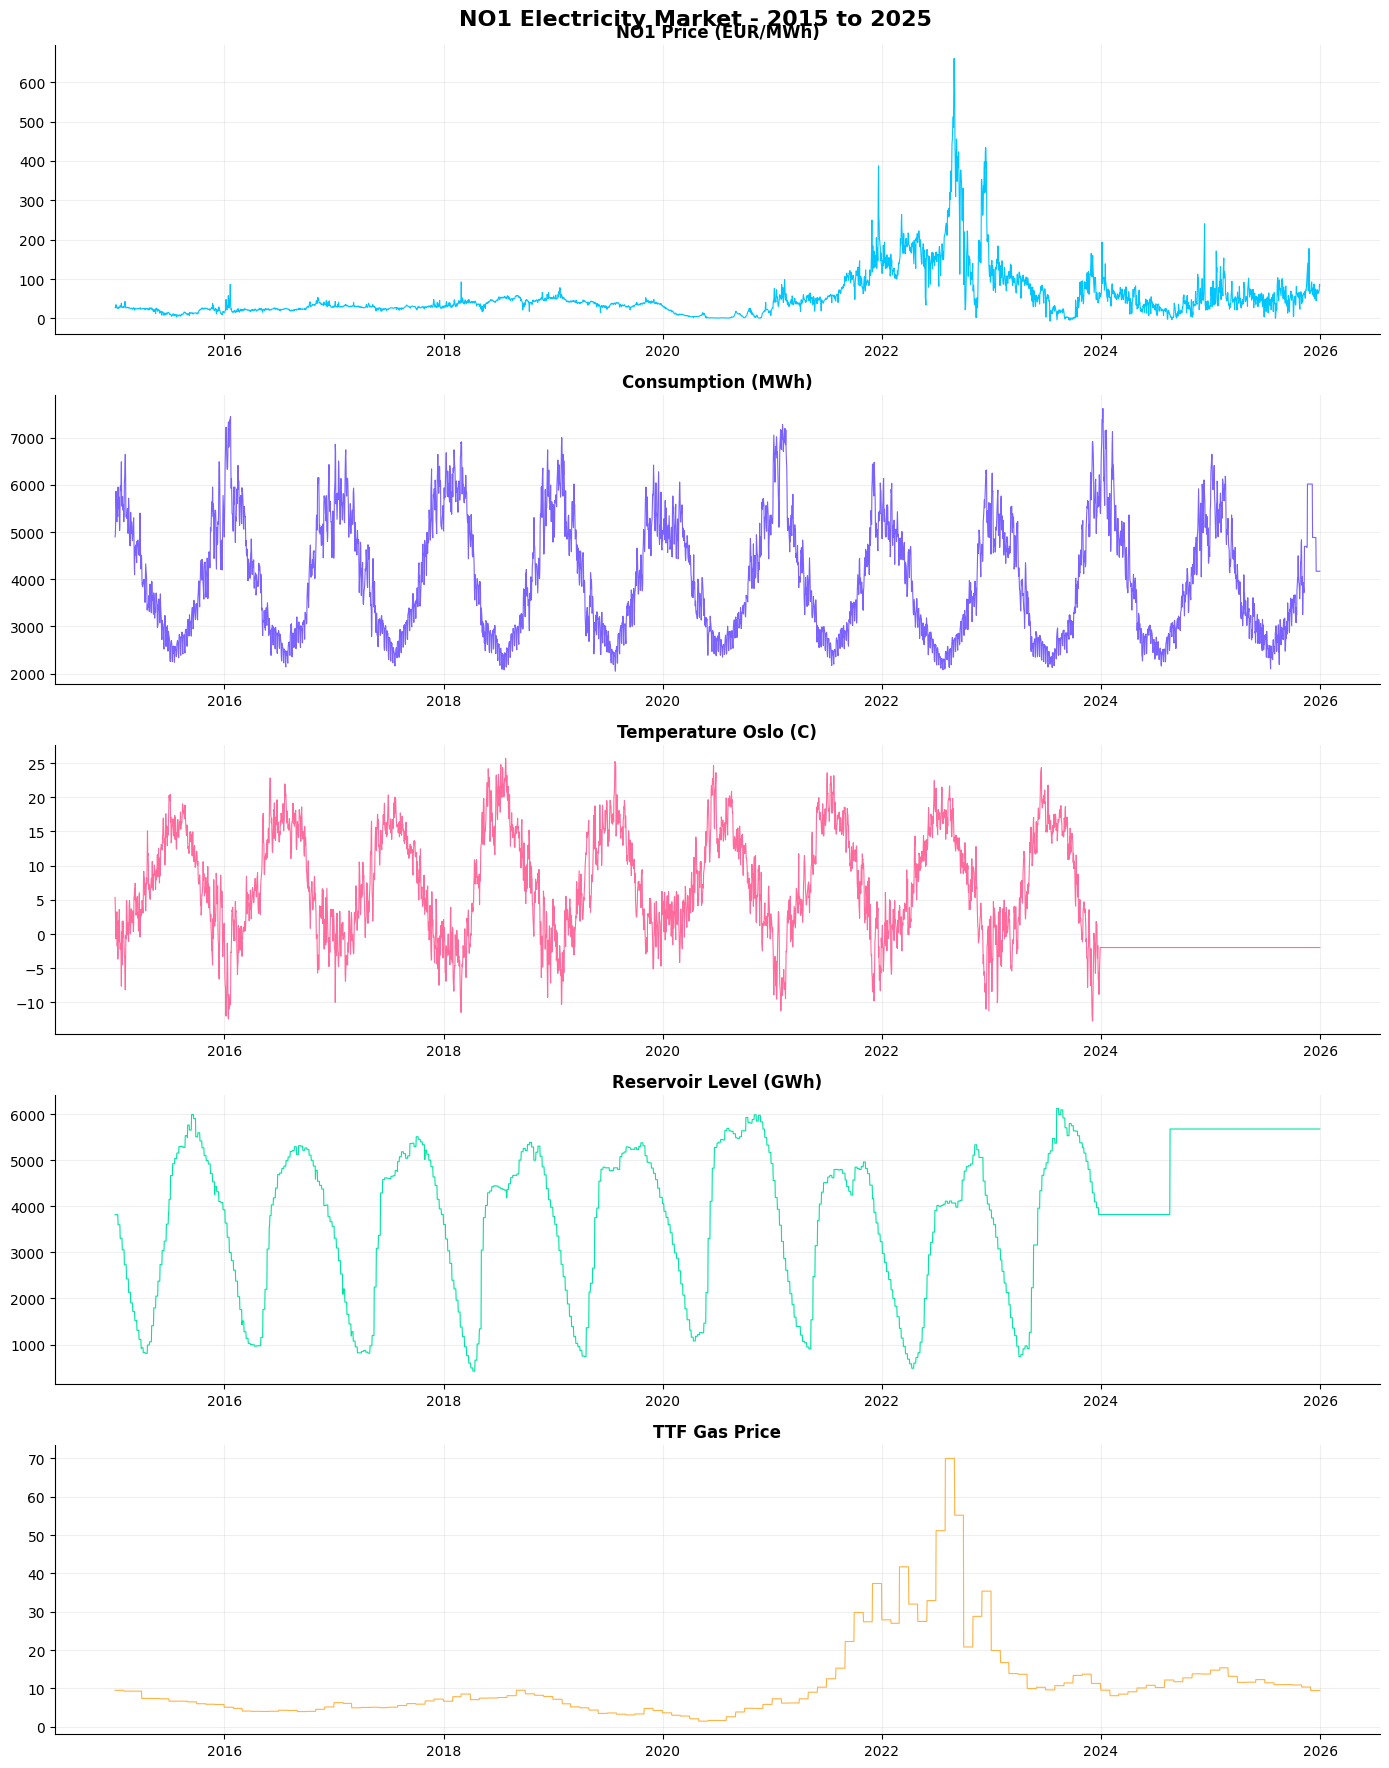

Plot saved!


In [15]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle('NO1 Electricity Market - 2015 to 2025', fontsize=16, fontweight='bold')

cols = ['price_mean', 'consumption', 'temperature', 'reservoir', 'ttf_gas']
titles = ['NO1 Price (EUR/MWh)', 'Consumption (MWh)', 
          'Temperature Oslo (C)', 'Reservoir Level (GWh)', 'TTF Gas Price']
colors = ['#00c6ff', '#7b61ff', '#ff6b9d', '#00e5a0', '#ffb347']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.plot(master_df.index, master_df[col], color=color, linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plot_path = os.path.join(DATA_PATH, 'exploratory_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

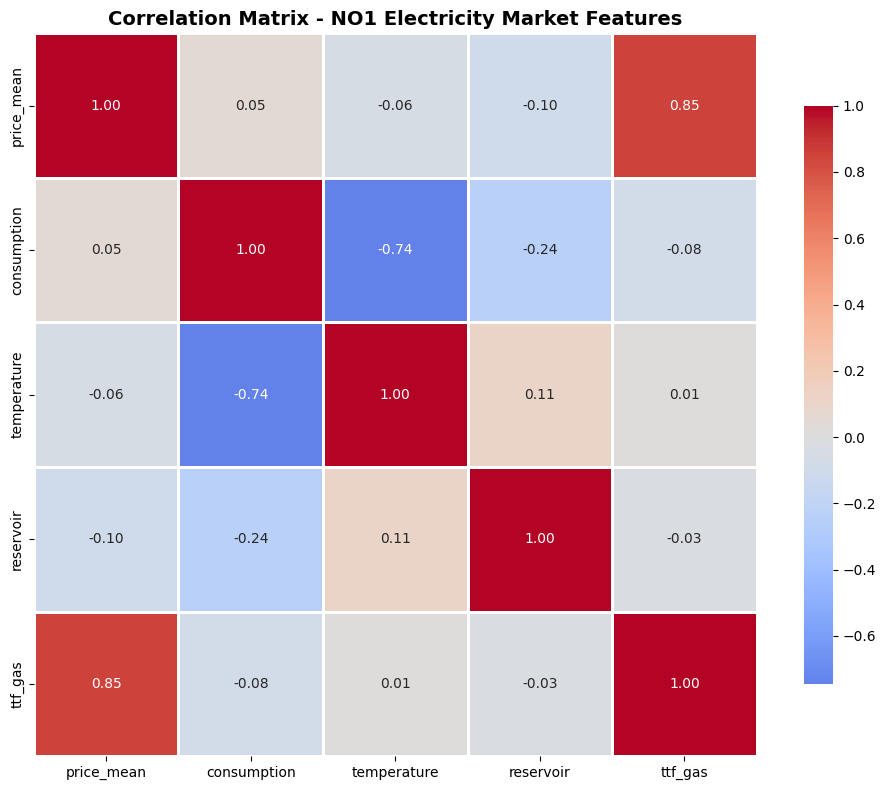

Correlation Matrix:
             price_mean  consumption  temperature  reservoir   ttf_gas
price_mean     1.000000     0.050859    -0.055409  -0.099536  0.853757
consumption    0.050859     1.000000    -0.744375  -0.242303 -0.081110
temperature   -0.055409    -0.744375     1.000000   0.109122  0.006372
reservoir     -0.099536    -0.242303     0.109122   1.000000 -0.027346
ttf_gas        0.853757    -0.081110     0.006372  -0.027346  1.000000

Key correlations with price:
Price vs TTF Gas:      0.854
Price vs Temperature:  -0.055
Price vs Consumption:  0.051
Price vs Reservoir:    -0.100


In [16]:
import seaborn as sns

# Select relevant columns for correlation
corr_cols = ['price_mean', 'consumption', 'temperature', 'reservoir', 'ttf_gas']
corr_data = master_df[corr_cols].dropna()

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - NO1 Electricity Market Features', 
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Correlation Matrix:")
print(corr_matrix)
print("\nKey correlations with price:")
print(f"Price vs TTF Gas:      {corr_matrix.loc['price_mean', 'ttf_gas']:.3f}")
print(f"Price vs Temperature:  {corr_matrix.loc['price_mean', 'temperature']:.3f}")
print(f"Price vs Consumption:  {corr_matrix.loc['price_mean', 'consumption']:.3f}")
print(f"Price vs Reservoir:    {corr_matrix.loc['price_mean', 'reservoir']:.3f}")

In [35]:

import os
DATA_PATH = r"C:\Users\ebs_p\OneDrive\Desktop\Temp"

# ═══════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════

variables = ['price_mean', 'consumption', 'temperature', 'reservoir', 'ttf_gas']
var_names = ['Price (EUR/MWh)', 'Consumption (MWh)', 'Temperature (°C)', 
             'Reservoir (GWh)', 'TTF Gas (EUR/MWh)']

print("="*90)
print("SUMMARY STATISTICS - NO1 ELECTRICITY MARKET (2015-2025)")
print("="*90)
print(f"{'Variable':<25} {'Mean':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10} {'Obs':<10}")
print("-"*90)

for var, name in zip(variables, var_names):
    mean_val = master_df[var].mean()
    std_val = master_df[var].std()
    min_val = master_df[var].min()
    max_val = master_df[var].max()
    count = master_df[var].count()
    
    print(f"{name:<25} {mean_val:<10.2f} {std_val:<10.2f} {min_val:<10.2f} {max_val:<10.2f} {count:<10}")

print("="*90)
print()

# Additional insights
print("ADDITIONAL INSIGHTS:")
print("-"*50)
print(f"Price coefficient of variation: {(master_df['price_mean'].std() / master_df['price_mean'].mean() * 100):.1f}%")
print(f"Maximum price: {master_df['price_mean'].max():.2f} EUR/MWh on {master_df['price_mean'].idxmax().date()}")
print(f"Minimum price: {master_df['price_mean'].min():.2f} EUR/MWh on {master_df['price_mean'].idxmin().date()}")
print(f"Days with price > 100 EUR/MWh: {(master_df['price_mean'] > 100).sum()} ({(master_df['price_mean'] > 100).sum()/len(master_df)*100:.1f}%)")
print(f"Days with price > 200 EUR/MWh: {(master_df['price_mean'] > 200).sum()} ({(master_df['price_mean'] > 200).sum()/len(master_df)*100:.1f}%)")

# Save summary statistics table
summary_table = pd.DataFrame({
    'Variable': var_names,
    'Mean': [master_df[var].mean() for var in variables],
    'Std_Dev': [master_df[var].std() for var in variables],
    'Min': [master_df[var].min() for var in variables],
    'Max': [master_df[var].max() for var in variables],
    'Observations': [master_df[var].count() for var in variables]
})
summary_table.to_csv(os.path.join(DATA_PATH, 'summary_statistics.csv'), index=False)

print("\n✓ Summary statistics saved to: summary_statistics.csv")

SUMMARY STATISTICS - NO1 ELECTRICITY MARKET (2015-2025)
Variable                  Mean       Std Dev    Min        Max        Obs       
------------------------------------------------------------------------------------------
Price (EUR/MWh)           54.71      61.11      -6.81      660.06     4017      
Consumption (MWh)         4024.30    1239.34    2050.75    7621.92    4017      
Temperature (°C)          5.84       7.89       -12.75     25.68      4017      
Reservoir (GWh)           3903.28    1608.97    422.00     6125.00    4017      
TTF Gas (EUR/MWh)         11.10      10.68      1.46       69.98      4017      

ADDITIONAL INSIGHTS:
--------------------------------------------------
Price coefficient of variation: 111.7%
Maximum price: 660.06 EUR/MWh on 2022-08-30
Minimum price: -6.81 EUR/MWh on 2023-07-16
Days with price > 100 EUR/MWh: 531 (13.2%)
Days with price > 200 EUR/MWh: 115 (2.9%)

✓ Summary statistics saved to: summary_statistics.csv


In [17]:
# Load clean data
master_df = pd.read_csv(os.path.join(DATA_PATH, 'clean_data.csv'), 
                        index_col='datetime', parse_dates=True)

print(f"Data loaded: {master_df.shape}")
print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")
print(master_df.head())

Data loaded: (4017, 5)
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00
            price_mean  consumption  temperature  reservoir  ttf_gas
datetime                                                            
2015-01-02   27.546667  4898.166667     5.354167     3819.0      9.5
2015-01-03   27.187917  4964.583333     3.070833     3819.0      9.5
2015-01-04   28.099167  5236.125000     0.112500     3819.0      9.5
2015-01-05   34.934167  5864.125000    -0.716667     3819.0      9.5
2015-01-06   29.001250  5599.208333     2.408333     3819.0      9.5


## 4. ARIMA Model – Stationarity Tests & Diagnostics
---

ADF Stationarity Test
ADF Statistic:  -4.3653
p-value:        0.0003
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5672

RESULT: Series is STATIONARY
No differencing needed


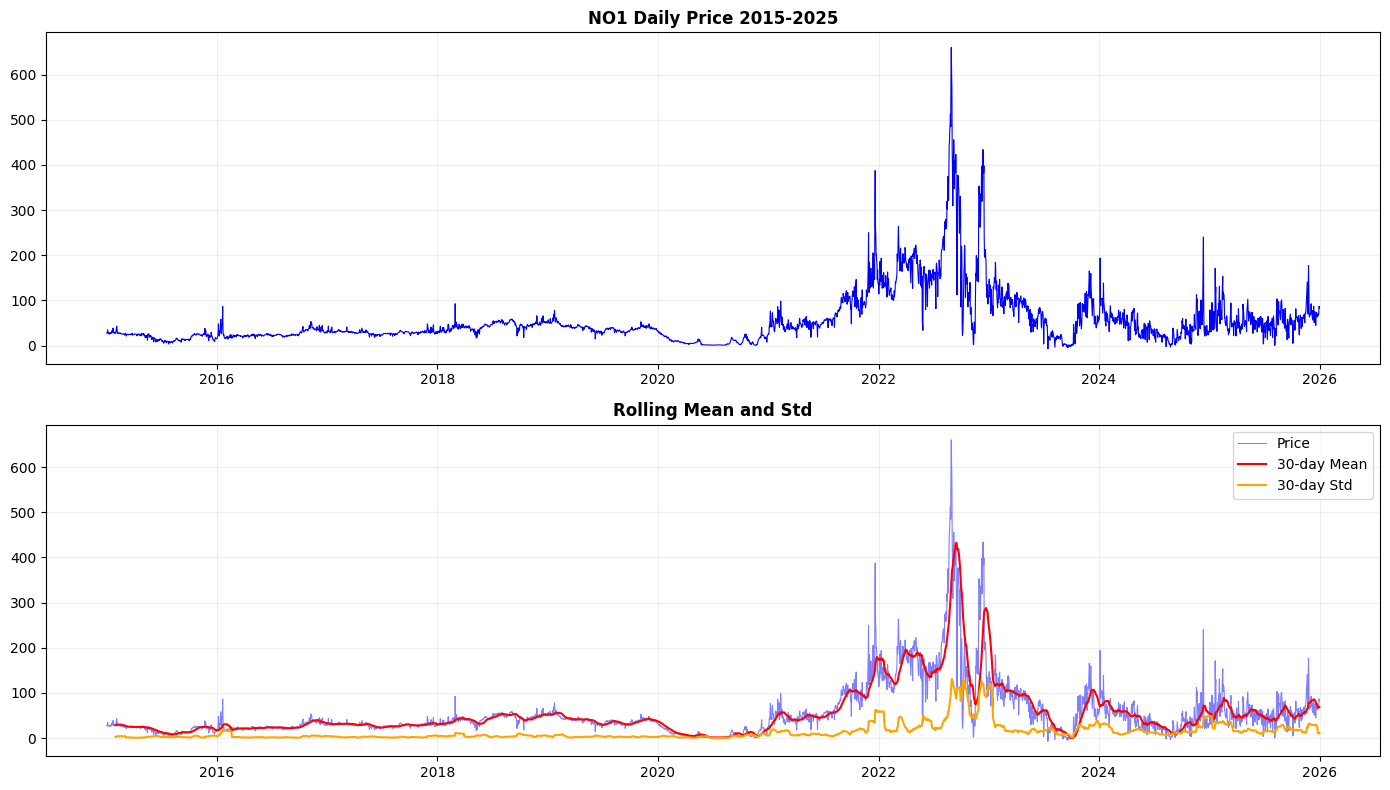

Plot saved!


In [18]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

price = master_df['price_mean'].dropna()

result = adfuller(price)
print('ADF Stationarity Test')
print('='*40)
print(f'ADF Statistic:  {result[0]:.4f}')
print(f'p-value:        {result[1]:.4f}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

print()
if result[1] < 0.05:
    print('RESULT: Series is STATIONARY')
    print('No differencing needed')
else:
    print('RESULT: NON-STATIONARY')
    print('Differencing needed')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

rolling_mean = price.rolling(window=30).mean()
rolling_std = price.rolling(window=30).std()

axes[0].plot(price.index, price.values, color='blue', linewidth=0.8)
axes[0].set_title('NO1 Daily Price 2015-2025', fontweight='bold')
axes[0].grid(True, alpha=0.2)

axes[1].plot(price.index, price.values, color='blue', linewidth=0.8, label='Price', alpha=0.5)
axes[1].plot(rolling_mean.index, rolling_mean.values, color='red', linewidth=1.5, label='30-day Mean')
axes[1].plot(rolling_std.index, rolling_std.values, color='orange', linewidth=1.5, label='30-day Std')
axes[1].set_title('Rolling Mean and Std', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'stationarity_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

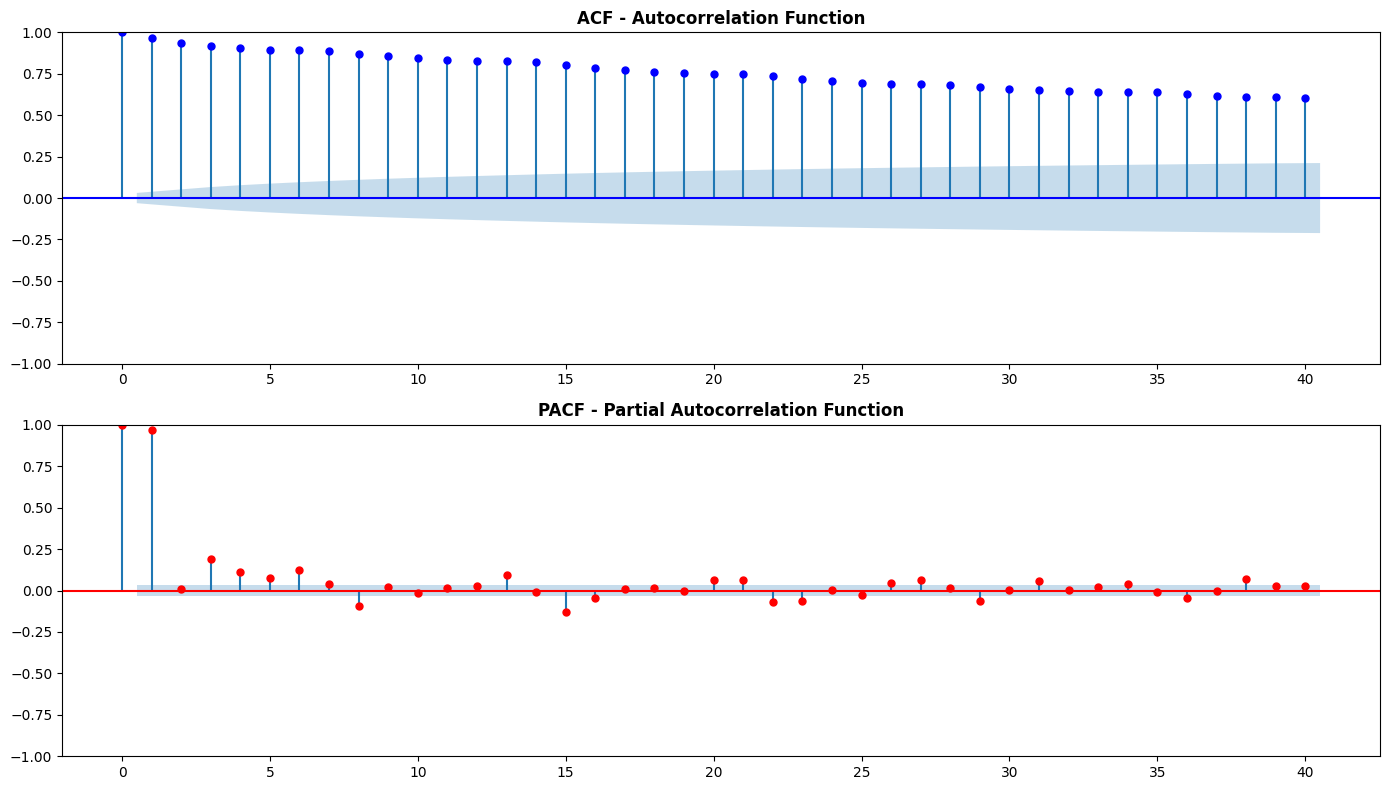

ACF PACF plots saved!


In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(price, lags=40, ax=axes[0], color='blue')
axes[0].set_title('ACF - Autocorrelation Function', fontweight='bold')

plot_pacf(price, lags=40, ax=axes[1], color='red')
axes[1].set_title('PACF - Partial Autocorrelation Function', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'acf_pacf_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("ACF PACF plots saved!")

## 4b. ARIMA – Model Fitting & Forecasting
---

In [20]:
from pmdarima import auto_arima

# Train/test split - last 90 days as test
train = price[:-90]
test = price[-90:]

print(f"Training: {train.index.min()} to {train.index.max()} | {len(train)} days")
print(f"Testing:  {test.index.min()} to {test.index.max()} | {len(test)} days")

# Fit auto_arima
print("\nFitting auto_arima... this takes 2-5 minutes")
arima_model = auto_arima(train,
                         start_p=1, max_p=5,
                         start_q=1, max_q=5,
                         d=0,
                         seasonal=False,
                         stepwise=True,
                         information_criterion='aic',
                         error_action='ignore',
                         suppress_warnings=True,
                         trace=True)

print("\nBest model found:")
print(arima_model.summary())

Training: 2015-01-02 00:00:00 to 2025-10-02 00:00:00 | 3927 days
Testing:  2025-10-03 00:00:00 to 2025-12-31 00:00:00 | 90 days

Fitting auto_arima... this takes 2-5 minutes
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=32760.145, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=45781.361, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=32760.857, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=41250.222, Time=0.33 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=32750.437, Time=0.59 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=32761.216, Time=0.21 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=32513.387, Time=1.14 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=32617.757, Time=0.13 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=32515.307, Time=1.12 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=32597.034, Time=2.50 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=32519.377, Time=0.98 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=inf,

ARIMA Model Performance
MAE:  18.09 EUR/MWh
RMSE: 27.10 EUR/MWh
MAPE: 46.43%


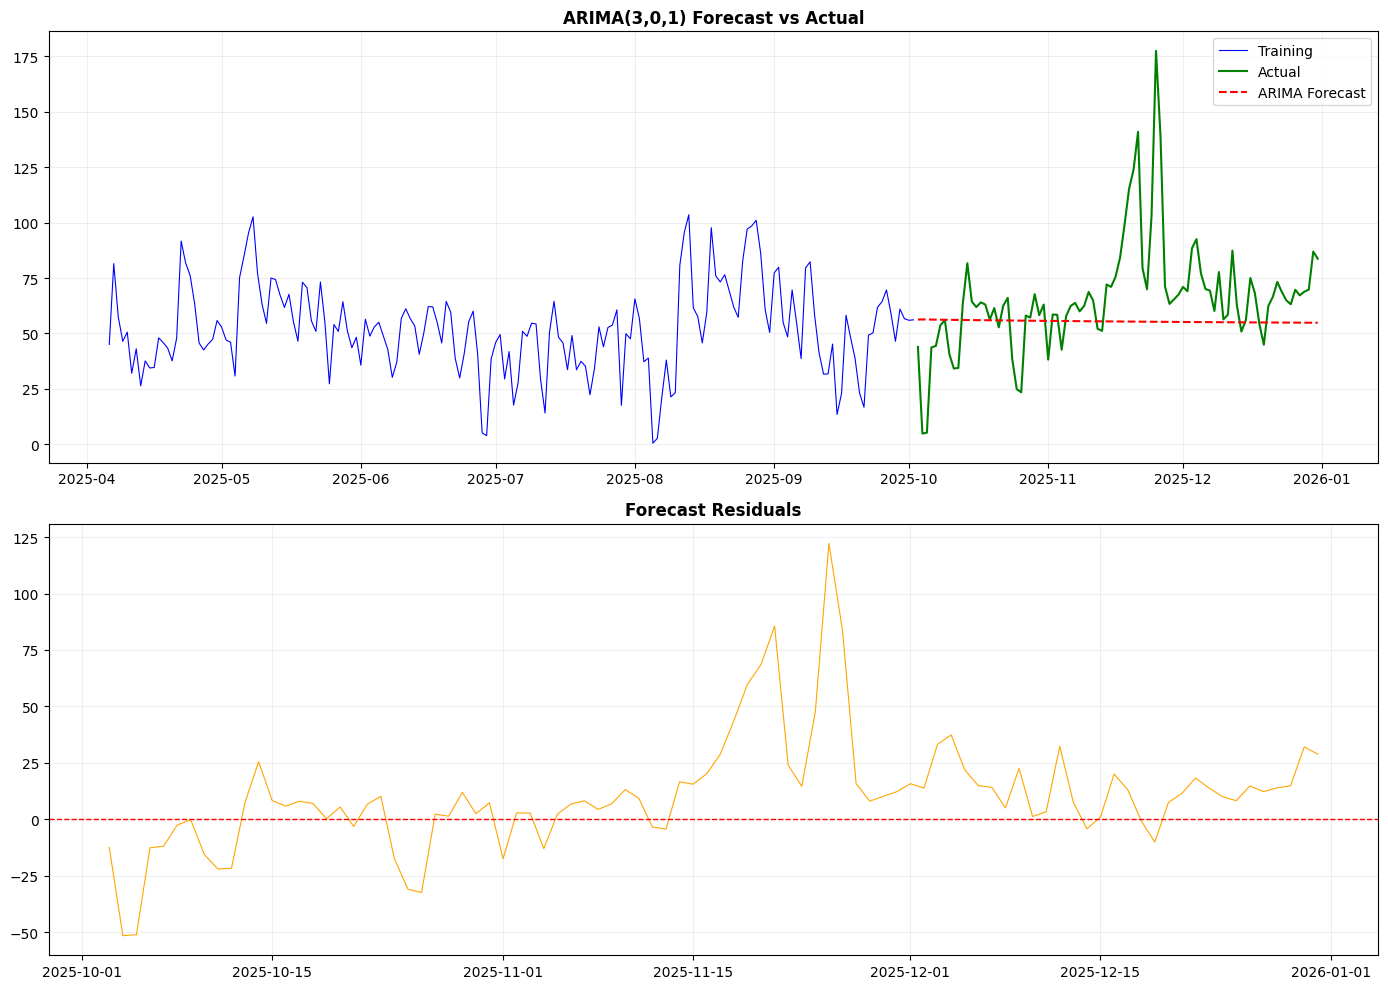


Plot saved!

ARIMA Results Summary:
Model: ARIMA(3,0,1)
MAE:  18.09 | RMSE: 27.10 | MAPE: 46.43%


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate forecast for test period
forecast = arima_model.predict(n_periods=90)
forecast_series = pd.Series(forecast, index=test.index)

# Calculate metrics
mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5
mape = (abs((test - forecast) / test) * 100).mean()

print('ARIMA Model Performance')
print('='*40)
print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')
print(f'MAPE: {mape:.2f}%')

# Plot forecast vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full history + forecast
axes[0].plot(train.index[-180:], train.values[-180:], color='blue', linewidth=0.8, label='Training')
axes[0].plot(test.index, test.values, color='green', linewidth=1.5, label='Actual')
axes[0].plot(forecast_series.index, forecast_series.values, color='red', linewidth=1.5, linestyle='--', label='ARIMA Forecast')
axes[0].set_title('ARIMA(3,0,1) Forecast vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Residuals
residuals = test.values - forecast
axes[1].plot(test.index, residuals, color='orange', linewidth=0.8)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Forecast Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'arima_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved!")
print(f"\nARIMA Results Summary:")
print(f"Model: ARIMA(3,0,1)")
print(f"MAE:  {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

In [22]:
import pickle

# Save ARIMA results for comparison later
arima_results = {
    'model': 'ARIMA(3,0,1)',
    'MAE': round(mae, 2),
    'RMSE': round(rmse, 2),
    'MAPE': round(mape, 2)
}

# Save model
with open(os.path.join(DATA_PATH, 'arima_model.pkl'), 'wb') as f:
    pickle.dump(arima_model, f)

# Save forecast
forecast_df = pd.DataFrame({
    'actual': test.values,
    'arima_forecast': forecast
}, index=test.index)
forecast_df.to_csv(os.path.join(DATA_PATH, 'arima_forecast.csv'))

print("ARIMA model saved!")
print("ARIMA forecast saved!")
print(f"\nResults: {arima_results}")
print("\nDay 2 COMPLETE! Moving to XGBoost...")

ARIMA model saved!
ARIMA forecast saved!

Results: {'model': 'ARIMA(3,0,1)', 'MAE': 18.09, 'RMSE': 27.1, 'MAPE': np.float64(46.43)}

Day 2 COMPLETE! Moving to XGBoost...


## 5. XGBoost – Feature Engineering
---

In [23]:
# Feature Engineering for XGBoost
df = master_df.copy()

# Lag features - previous days prices
df['price_lag1'] = df['price_mean'].shift(1)
df['price_lag7'] = df['price_mean'].shift(7)
df['price_lag14'] = df['price_mean'].shift(14)
df['price_lag30'] = df['price_mean'].shift(30)

# Rolling averages
df['price_roll7'] = df['price_mean'].shift(1).rolling(7).mean()
df['price_roll30'] = df['price_mean'].shift(1).rolling(30).mean()

# Rolling std (volatility)
df['price_std7'] = df['price_mean'].shift(1).rolling(7).std()
df['price_std30'] = df['price_mean'].shift(1).rolling(30).std()

# Calendar features
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['dayofyear'] = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# Drop NaN rows created by lags
df = df.dropna()

print(f"Features shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nFeature columns:")
print(df.columns.tolist())

Features shape: (3987, 18)
Date range: 2015-02-01 00:00:00 to 2025-12-31 00:00:00

Feature columns:
['price_mean', 'consumption', 'temperature', 'reservoir', 'ttf_gas', 'price_lag1', 'price_lag7', 'price_lag14', 'price_lag30', 'price_roll7', 'price_roll30', 'price_std7', 'price_std30', 'dayofweek', 'month', 'quarter', 'dayofyear', 'is_weekend']


## 5b. XGBoost – Model Training & Evaluation
---

In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define features and target
FEATURES = ['consumption', 'temperature', 'reservoir', 'ttf_gas',
            'price_lag1', 'price_lag7', 'price_lag14', 'price_lag30',
            'price_roll7', 'price_roll30', 'price_std7', 'price_std30',
            'dayofweek', 'month', 'quarter', 'dayofyear', 'is_weekend']

TARGET = 'price_mean'

X = df[FEATURES]
y = df[TARGET]

# Train/test split - last 90 days as test (same as ARIMA)
X_train = X[:-90]
X_test = X[-90:]
y_train = y[:-90]
y_test = y[-90:]

print(f"Training: {X_train.index.min()} to {X_train.index.max()} | {len(X_train)} rows")
print(f"Testing:  {X_test.index.min()} to {X_test.index.max()} | {len(X_test)} rows")

# Train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=100)

# Predict
y_pred = xgb_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = (abs((y_test - y_pred) / y_test) * 100).mean()

print(f"\nXGBoost Model Performance")
print("="*40)
print(f"MAE:  {mae:.2f} EUR/MWh")
print(f"RMSE: {rmse:.2f} EUR/MWh")
print(f"MAPE: {mape:.2f}%")

Training: 2015-02-01 00:00:00 to 2025-10-02 00:00:00 | 3897 rows
Testing:  2025-10-03 00:00:00 to 2025-12-31 00:00:00 | 90 rows
[0]	validation_0-rmse:26.40181
[100]	validation_0-rmse:17.31989
[116]	validation_0-rmse:17.33208

XGBoost Model Performance
MAE:  12.30 EUR/MWh
RMSE: 17.05 EUR/MWh
MAPE: 27.95%


## 6. SHAP Explainability Analysis
---

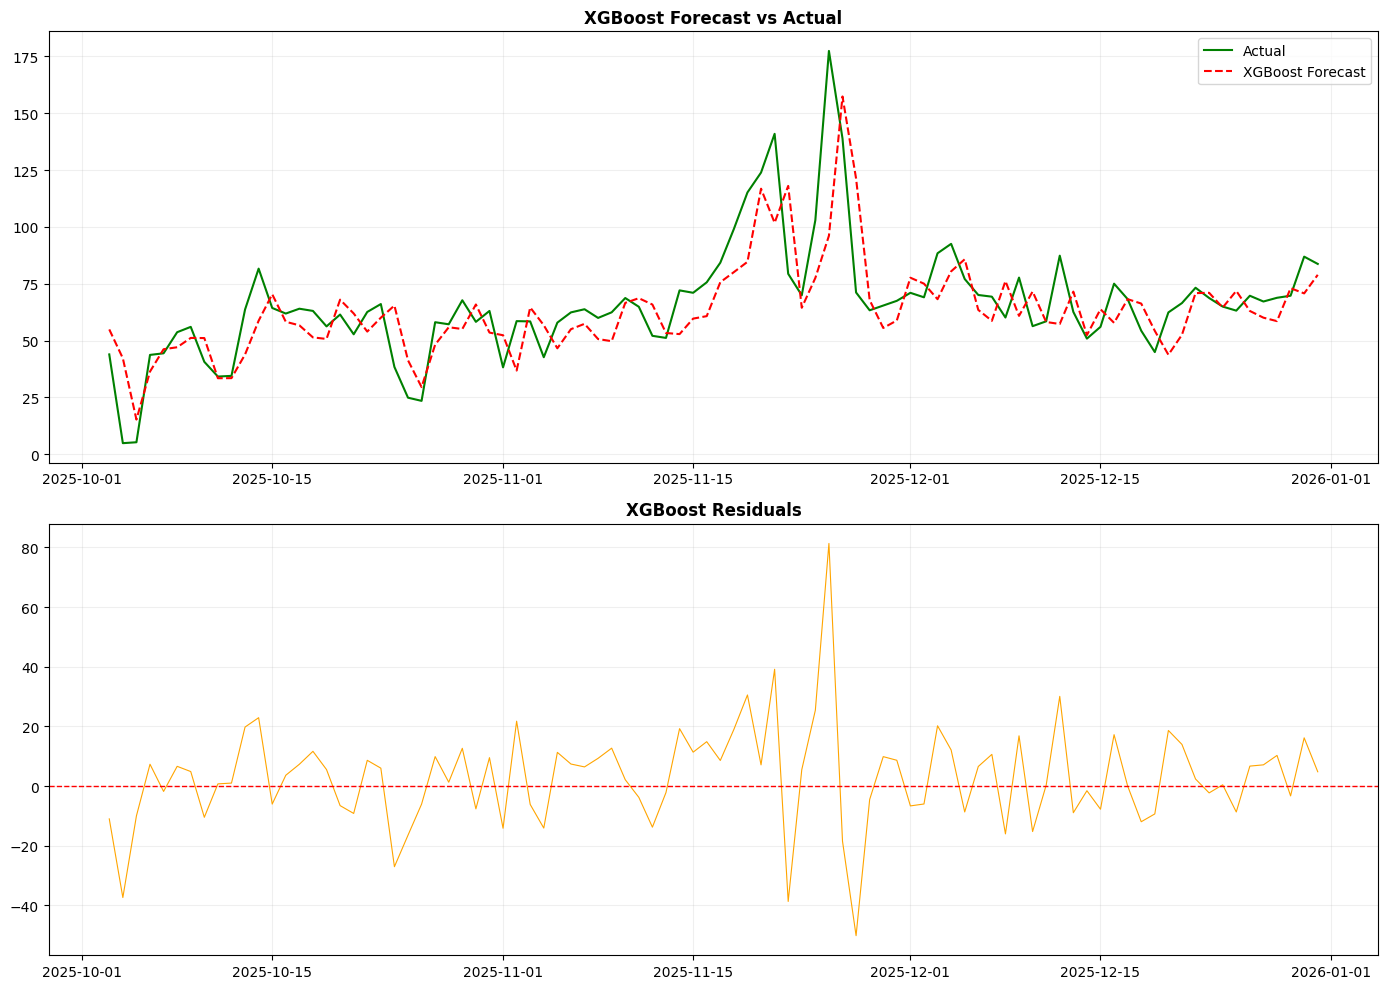

Calculating SHAP values...


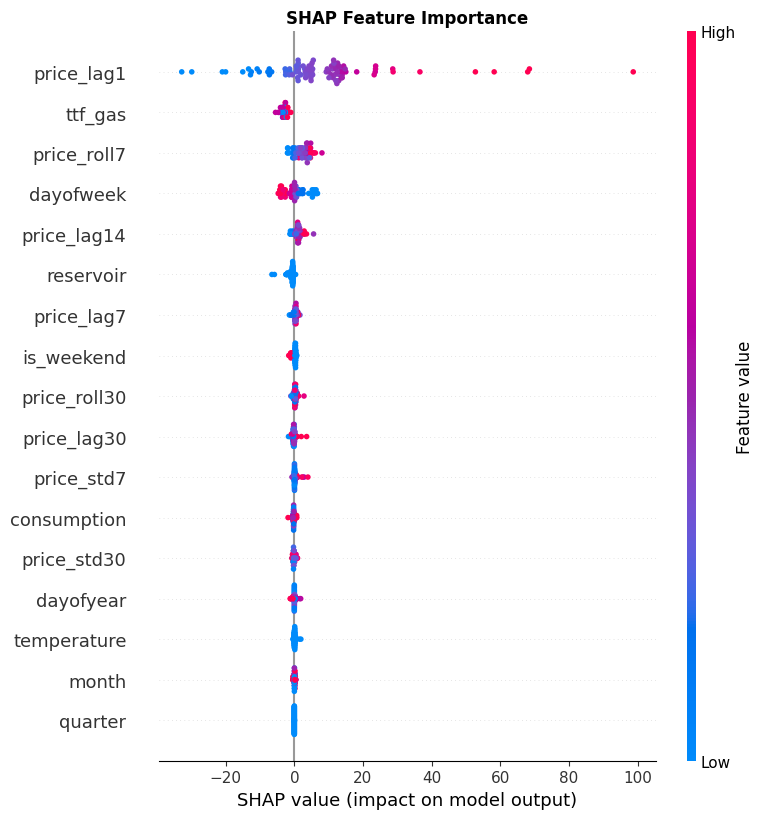

Plots saved!


In [25]:
import shap

# Plot forecast vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_test.index, y_test.values, color='green', linewidth=1.5, label='Actual')
axes[0].plot(y_test.index, y_pred, color='red', linewidth=1.5, linestyle='--', label='XGBoost Forecast')
axes[0].set_title('XGBoost Forecast vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

residuals = y_test.values - y_pred
axes[1].plot(y_test.index, residuals, color='orange', linewidth=0.8)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('XGBoost Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'xgb_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

# SHAP feature importance
print("Calculating SHAP values...")
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'shap_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved!")

In [26]:
import pickle

with open(os.path.join(DATA_PATH, 'xgb_model.pkl'), 'wb') as f:
    pickle.dump(xgb_model, f)

xgb_forecast_df = pd.DataFrame({
    'actual': y_test.values,
    'xgb_forecast': y_pred
}, index=y_test.index)
xgb_forecast_df.to_csv(os.path.join(DATA_PATH, 'xgb_forecast.csv'))

xgb_results = {
    'model': 'XGBoost',
    'MAE': round(mae, 2),
    'RMSE': round(rmse, 2),
    'MAPE': round(mape, 2)
}

print("XGBoost model saved!")
print(f"Results: {xgb_results}")
print("\nDay 3 COMPLETE! Moving to Quantile model...")

XGBoost model saved!
Results: {'model': 'XGBoost', 'MAE': 12.3, 'RMSE': 17.05, 'MAPE': np.float64(27.95)}

Day 3 COMPLETE! Moving to Quantile model...


## 7. Quantile XGBoost – Probabilistic Forecasting
---

In [27]:
# XGBoost Quantile Regression
# Train 3 models: q=0.10 (low), q=0.50 (median), q=0.90 (high)

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    print(f"Training quantile q={q}...")
    model_q = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:quantileerror',
        quantile_alpha=q
    )
    
    model_q.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)
    
    quantile_models[q] = model_q
    quantile_preds[q] = model_q.predict(X_test)
    print(f"Done q={q}")

print("\nAll quantile models trained!")

# Build results dataframe
quantile_df = pd.DataFrame({
    'actual': y_test.values,
    'q10': quantile_preds[0.10],
    'q50': quantile_preds[0.50],
    'q90': quantile_preds[0.90]
}, index=y_test.index)

# Coverage score - how often does actual fall within q10-q90 interval
coverage = ((quantile_df['actual'] >= quantile_df['q10']) & 
            (quantile_df['actual'] <= quantile_df['q90'])).mean() * 100

print(f"\nInterval Coverage Score: {coverage:.1f}%")
print(f"(Target: ~80% for 10th-90th percentile interval)")
print(quantile_df.head(10))

Training quantile q=0.1...
Done q=0.1
Training quantile q=0.5...
Done q=0.5
Training quantile q=0.9...
Done q=0.9

All quantile models trained!

Interval Coverage Score: 63.3%
(Target: ~80% for 10th-90th percentile interval)
               actual        q10        q50        q90
datetime                                              
2025-10-03  43.908333  44.757305  54.973511  61.460258
2025-10-04   4.855000  31.246338  39.835175  54.210636
2025-10-05   5.257083  10.385391  19.505072  21.134935
2025-10-06  43.689583  20.382843  32.883812  41.313858
2025-10-07  44.395417  35.751522  48.240467  62.420765
2025-10-08  53.677083  34.482208  43.609318  63.754276
2025-10-09  56.027083  40.161938  47.333447  64.277351
2025-10-10  40.640000  42.919827  46.628025  63.012531
2025-10-11  34.167083  20.960327  34.949108  50.408386
2025-10-12  34.466250  19.396040  36.895832  45.944920


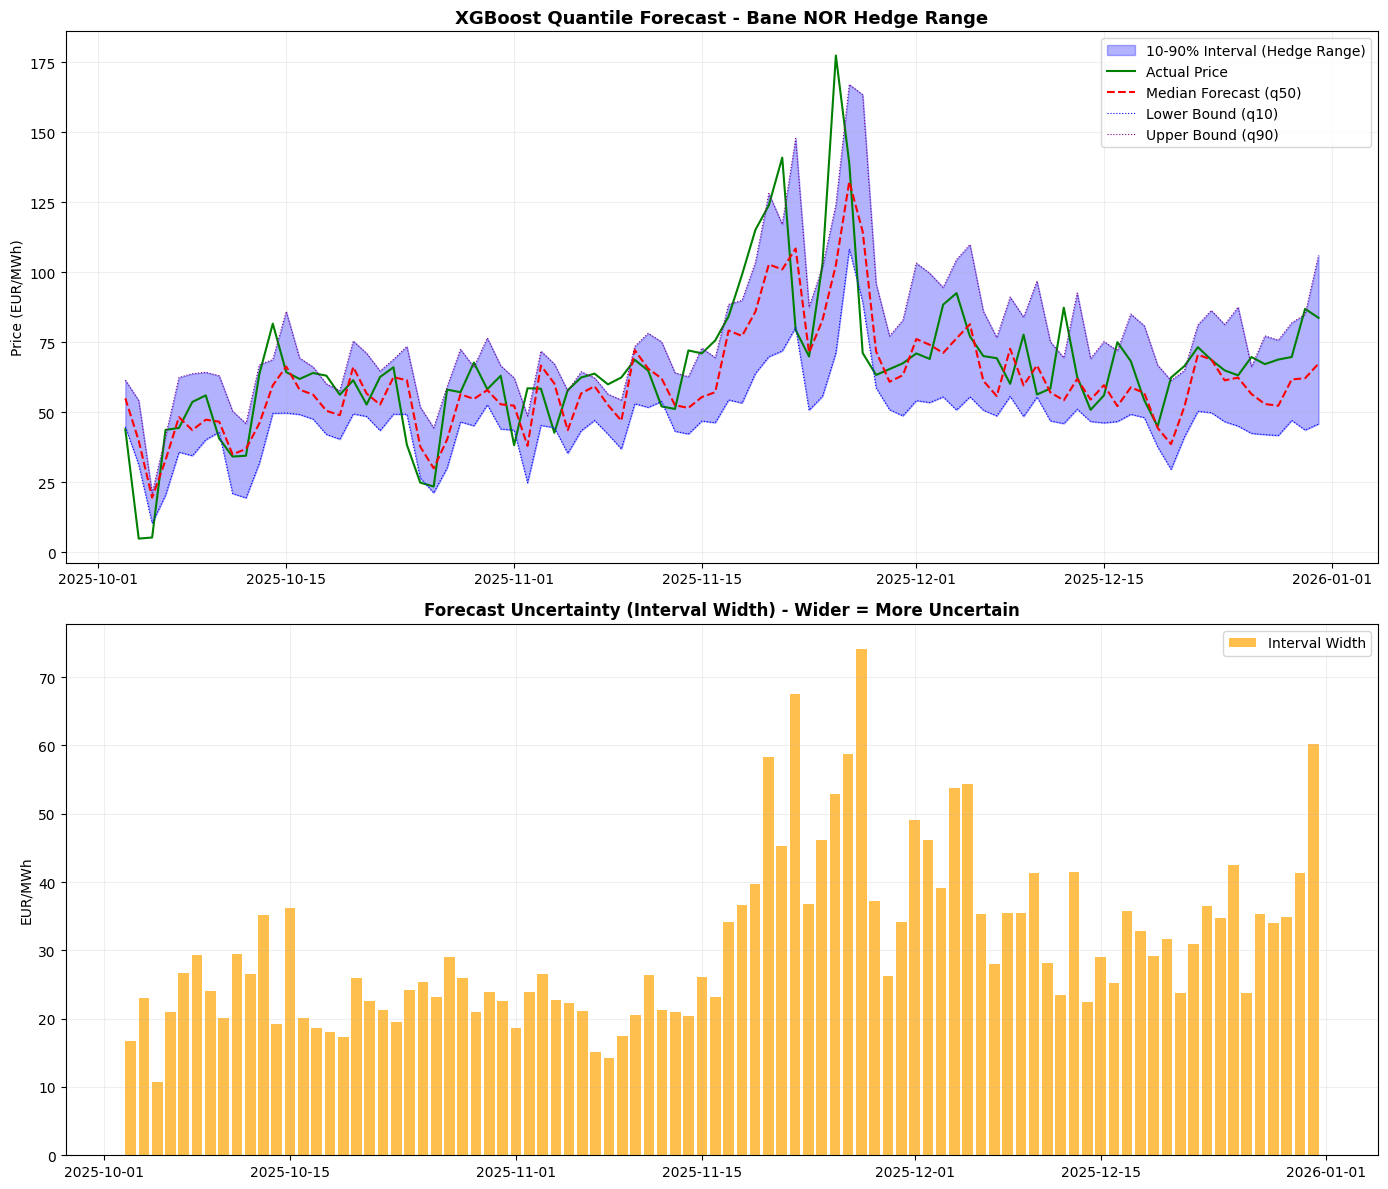

Quantile plots and models saved!

Coverage Score: 63.3%
Average Interval Width: 30.91 EUR/MWh
Max Interval Width: 74.10 EUR/MWh


In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 - Prediction intervals
axes[0].fill_between(quantile_df.index, 
                     quantile_df['q10'], 
                     quantile_df['q90'],
                     alpha=0.3, color='blue', label='10-90% Interval (Hedge Range)')
axes[0].plot(quantile_df.index, quantile_df['actual'], 
             color='green', linewidth=1.5, label='Actual Price')
axes[0].plot(quantile_df.index, quantile_df['q50'], 
             color='red', linewidth=1.5, linestyle='--', label='Median Forecast (q50)')
axes[0].plot(quantile_df.index, quantile_df['q10'], 
             color='blue', linewidth=0.8, linestyle=':', label='Lower Bound (q10)')
axes[0].plot(quantile_df.index, quantile_df['q90'], 
             color='purple', linewidth=0.8, linestyle=':', label='Upper Bound (q90)')
axes[0].set_title('XGBoost Quantile Forecast - Bane NOR Hedge Range', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Plot 2 - Interval width (uncertainty)
interval_width = quantile_df['q90'] - quantile_df['q10']
axes[1].bar(quantile_df.index, interval_width, color='orange', alpha=0.7, label='Interval Width')
axes[1].set_title('Forecast Uncertainty (Interval Width) - Wider = More Uncertain', fontweight='bold')
axes[1].set_ylabel('EUR/MWh')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'quantile_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save results
quantile_df.to_csv(os.path.join(DATA_PATH, 'quantile_forecast.csv'))

with open(os.path.join(DATA_PATH, 'quantile_models.pkl'), 'wb') as f:
    pickle.dump(quantile_models, f)

print("Quantile plots and models saved!")
print(f"\nCoverage Score: {coverage:.1f}%")
print(f"Average Interval Width: {interval_width.mean():.2f} EUR/MWh")
print(f"Max Interval Width: {interval_width.max():.2f} EUR/MWh")

## 8. Final Model Comparison
---

FINAL MODEL COMPARISON - NO1 Electricity Forecasting
                 Model   MAE  RMSE  MAPE
          ARIMA(3,0,1) 18.09 27.10 46.43
               XGBoost 12.30 17.05 27.95
XGBoost Quantile (q50) 12.20 16.68 27.91

Quantile Coverage Score: 63.3%
Average Hedge Interval:  30.91 EUR/MWh


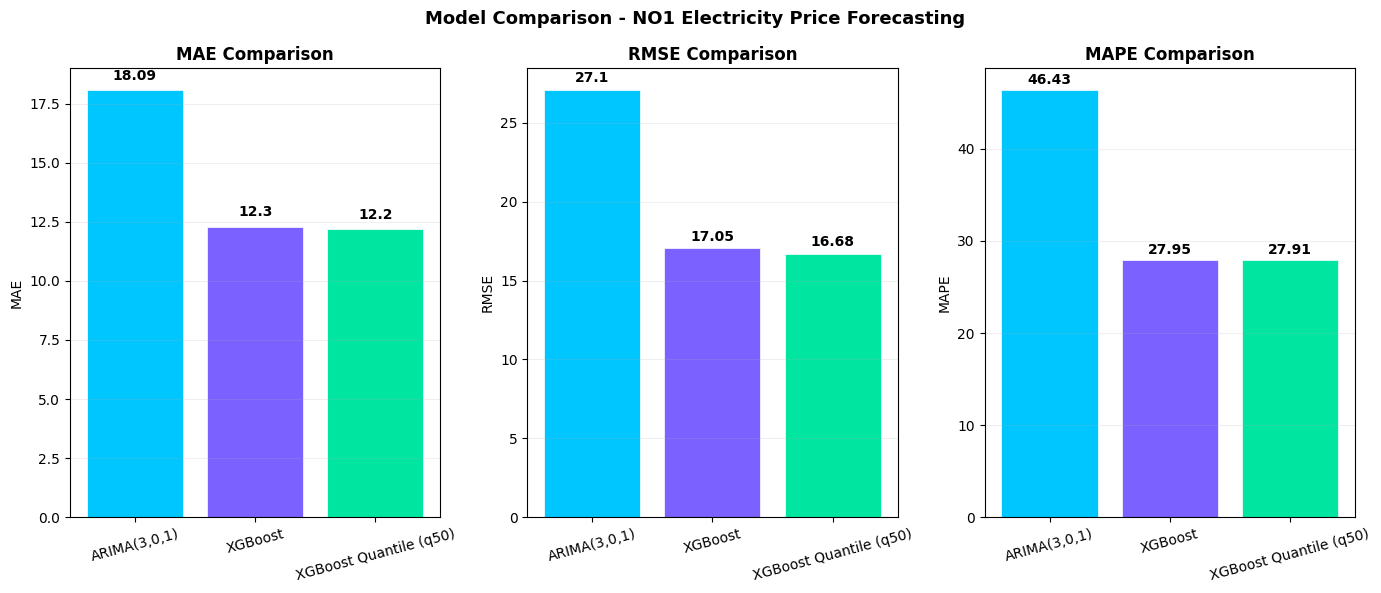


Comparison chart saved!


In [29]:
# Final comparison of all 3 models
print("="*55)
print("FINAL MODEL COMPARISON - NO1 Electricity Forecasting")
print("="*55)

results = {
    'Model':  ['ARIMA(3,0,1)', 'XGBoost', 'XGBoost Quantile (q50)'],
    'MAE':    [18.09, 12.30, round(mean_absolute_error(y_test, quantile_preds[0.50]), 2)],
    'RMSE':   [27.10, 17.05, round(mean_squared_error(y_test, quantile_preds[0.50])**0.5, 2)],
    'MAPE':   [46.43, 27.95, round((abs((y_test - quantile_preds[0.50]) / y_test)*100).mean(), 2)]
}

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(DATA_PATH, 'model_comparison.csv'), index=False)

print(results_df.to_string(index=False))
print(f"\nQuantile Coverage Score: {coverage:.1f}%")
print(f"Average Hedge Interval:  {interval_width.mean():.2f} EUR/MWh")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
models = results['Model']
colors = ['#00c6ff', '#7b61ff', '#00e5a0']
metrics = ['MAE', 'RMSE', 'MAPE']

for ax, metric in zip(axes, metrics):
    values = results[metric]
    bars = ax.bar(models, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.2, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Model Comparison - NO1 Electricity Price Forecasting', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nComparison chart saved!")

In [30]:
def pinball_loss(actual, predicted, q):
    errors = actual - predicted
    loss = np.where(errors >= 0, q * errors, (q - 1) * errors)
    return round(loss.mean(), 4)

pb_q10 = pinball_loss(y_test.values, quantile_preds[0.10], 0.10)
pb_q50 = pinball_loss(y_test.values, quantile_preds[0.50], 0.50)
pb_q90 = pinball_loss(y_test.values, quantile_preds[0.90], 0.90)

print("Pinball Loss Results")
print("="*40)
print(f"Pinball Loss q10: {pb_q10}")
print(f"Pinball Loss q50: {pb_q50}")
print(f"Pinball Loss q90: {pb_q90}")
print(f"\nNote: Lower is better")

pinball_results = {
    'Metric': ['MAE', 'RMSE', 'MAPE', 
               'Pinball q10', 'Pinball q50', 'Pinball q90',
               'Coverage Score', 'Avg Hedge Interval'],
    'ARIMA(3,0,1)': [18.09, 27.10, 46.43, '-', '-', '-', '-', '-'],
    'XGBoost': [12.30, 17.05, 27.95, '-', '-', '-', '-', '-'],
    'XGBoost Quantile': [12.20, 16.68, 27.91, 
                         pb_q10, pb_q50, pb_q90,
                         f'{coverage:.1f}%', f'{interval_width.mean():.2f}']
}

results_full_df = pd.DataFrame(pinball_results)
results_full_df.to_csv(os.path.join(DATA_PATH, 'full_results.csv'), index=False)

print("\nFull results table:")
print(results_full_df.to_string(index=False))
print("\nSaved to full_results.csv!")

Pinball Loss Results
Pinball Loss q10: 2.7545
Pinball Loss q50: 6.0997
Pinball Loss q90: 3.2454

Note: Lower is better

Full results table:
            Metric ARIMA(3,0,1) XGBoost XGBoost Quantile
               MAE        18.09    12.3             12.2
              RMSE         27.1   17.05            16.68
              MAPE        46.43   27.95            27.91
       Pinball q10            -       -           2.7545
       Pinball q50            -       -           6.0997
       Pinball q90            -       -           3.2454
    Coverage Score            -       -            63.3%
Avg Hedge Interval            -       -            30.91

Saved to full_results.csv!


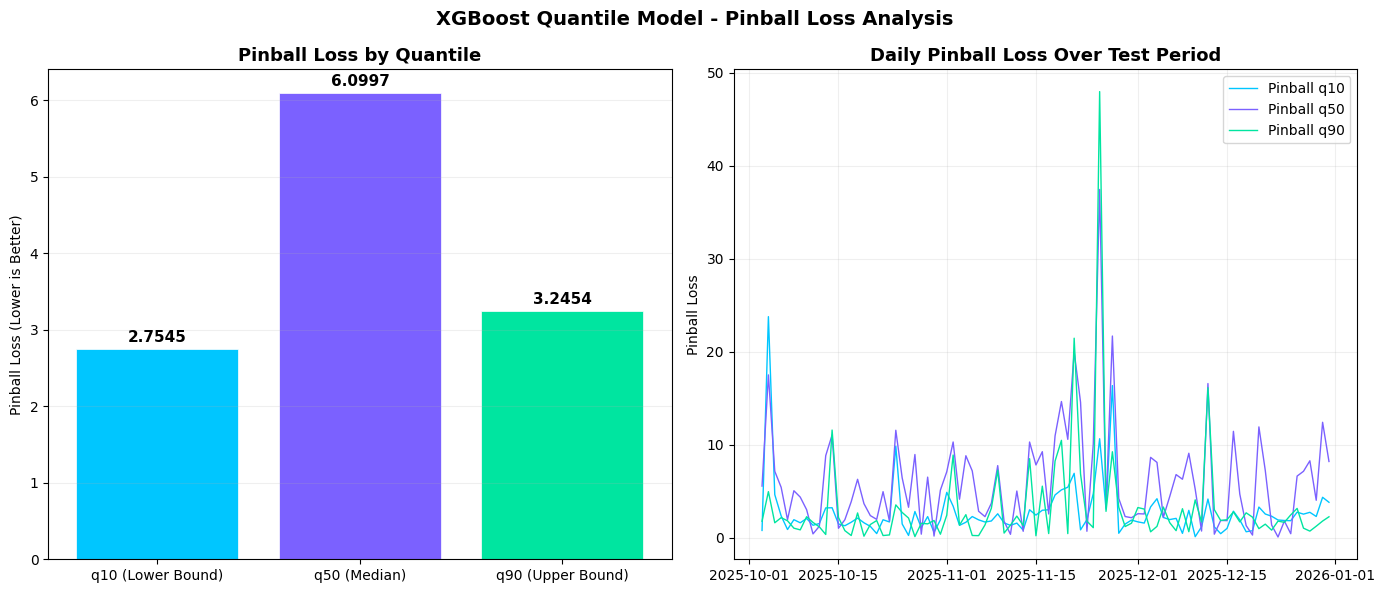

Pinball loss plot saved!


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - Pinball loss bar chart
quantiles_labels = ['q10 (Lower Bound)', 'q50 (Median)', 'q90 (Upper Bound)']
pinball_values = [pb_q10, pb_q50, pb_q90]
colors = ['#00c6ff', '#7b61ff', '#00e5a0']

bars = axes[0].bar(quantiles_labels, pinball_values, color=colors, 
                   edgecolor='white', linewidth=0.5)
axes[0].set_title('Pinball Loss by Quantile', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Pinball Loss (Lower is Better)')
axes[0].grid(True, alpha=0.2, axis='y')
for bar, val in zip(bars, pinball_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2 - Daily pinball loss over test period
pb_q10_daily = np.where(y_test.values - quantile_preds[0.10] >= 0,
                        0.10 * (y_test.values - quantile_preds[0.10]),
                        0.90 * (quantile_preds[0.10] - y_test.values))

pb_q50_daily = np.where(y_test.values - quantile_preds[0.50] >= 0,
                        0.50 * (y_test.values - quantile_preds[0.50]),
                        0.50 * (quantile_preds[0.50] - y_test.values))

pb_q90_daily = np.where(y_test.values - quantile_preds[0.90] >= 0,
                        0.90 * (y_test.values - quantile_preds[0.90]),
                        0.10 * (quantile_preds[0.90] - y_test.values))

axes[1].plot(y_test.index, pb_q10_daily, color='#00c6ff', linewidth=1, label='Pinball q10')
axes[1].plot(y_test.index, pb_q50_daily, color='#7b61ff', linewidth=1, label='Pinball q50')
axes[1].plot(y_test.index, pb_q90_daily, color='#00e5a0', linewidth=1, label='Pinball q90')
axes[1].set_title('Daily Pinball Loss Over Test Period', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Pinball Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.suptitle('XGBoost Quantile Model - Pinball Loss Analysis', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'pinball_loss_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Pinball loss plot saved!")

## 9. Hyperparameter Tuning (RandomizedSearchCV)
---

In [32]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np

# Define parameter grid to search
param_grid = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# TimeSeriesSplit - respects time order (important for your data!)
tscv = TimeSeriesSplit(n_splits=5)

# Random search
print("Starting hyperparameter tuning...")
print("This will take 10-15 minutes - let it run!")

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, eval_metric='rmse'),
    param_distributions=param_grid,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
print(random_search.best_params_)
print(f"\nBest CV MAE: {-random_search.best_score_:.2f} EUR/MWh")

Starting hyperparameter tuning...
This will take 10-15 minutes - let it run!
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}

Best CV MAE: 15.81 EUR/MWh


In [33]:
# Define parameter grid to search
param_grid = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# TimeSeriesSplit - respects time order (important for your data!)
tscv = TimeSeriesSplit(n_splits=5)

# Random search
print("Starting hyperparameter tuning...")
print("This will take 10-15 minutes - let it run!")

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, eval_metric='rmse'),
    param_distributions=param_grid,
    n_iter=100,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
print(random_search.best_params_)
print(f"\nBest CV MAE: {-random_search.best_score_:.2f} EUR/MWh")

Starting hyperparameter tuning...
This will take 10-15 minutes - let it run!
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters found:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}

Best CV MAE: 15.81 EUR/MWh


In [34]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

best_params = {
    'subsample': 0.7,
    'n_estimators': 300,
    'min_child_weight': 5,
    'max_depth': 8,
    'learning_rate': 0.05,
    'gamma': 0.1,
    'colsample_bytree': 0.6
}

xgb_tuned = XGBRegressor(**best_params, random_state=42, eval_metric='rmse')
xgb_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_tuned.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned) ** 0.5
mape_tuned = (abs((y_test - y_pred_tuned) / y_test) * 100).mean()

print("Tuned XGBoost Results")
print("="*40)
print(f"MAE:  {mae_tuned:.2f} EUR/MWh")
print(f"RMSE: {rmse_tuned:.2f} EUR/MWh")
print(f"MAPE: {mape_tuned:.2f}%")
print()
print("Improvement vs Original:")
print(f"MAE:  12.30 -> {mae_tuned:.2f}")
print(f"RMSE: 17.05 -> {rmse_tuned:.2f}")
print(f"MAPE: 27.95% -> {mape_tuned:.2f}%")

Tuned XGBoost Results
MAE:  12.67 EUR/MWh
RMSE: 17.30 EUR/MWh
MAPE: 28.67%

Improvement vs Original:
MAE:  12.30 -> 12.67
RMSE: 17.05 -> 17.30
MAPE: 27.95% -> 28.67%
